# Medical Insurance Cost Prediction

### Student
Pranith Varma Pakalapati

### Objective
This assignment develops a machine learning model to predict individual medical insurance charges based on demographic and health-related factors such as age, BMI, smoking status, number of children, gender, and region.

# 1. Introduction

Medical insurance companies estimate healthcare costs using several personal attributes. This project builds machine learning models to predict medical insurance charges using demographic and health-related information.

# 2. Business Problem

The objective of this project is to predict an individual's medical insurance charges using personal information such as age, BMI, smoking status, number of children, sex, and region.

# 3. Objectives

- Understand the dataset.
- Perform exploratory data analysis.
- Prepare the data for machine learning.
- Train multiple regression models.
- Compare model performance.
- Identify the factors affecting insurance costs.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["steelblue"])
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("All libraries imported successfully!")

All libraries imported successfully!


# 4. Load the Dataset

The first step in any data science project is loading and inspecting the dataset. This helps us understand the available features, identify the target variable, and verify that the dataset has been imported correctly.

The Medical Cost Personal Dataset contains demographic and health-related information used to predict individual medical insurance charges.

In [2]:
# ==========================================
# Load Dataset
# ==========================================
from pathlib import Path

# Support both launching Jupyter from the repository root and from notebooks/
DATA_PATH = Path("data/insurance.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/insurance.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset path:", DATA_PATH.resolve())
print("Dataset shape:", df.shape)
df.head()

Dataset path: /mnt/data/repo_fix/Assignment-1-CMPE-255-main/assignment-part-1/data/insurance.csv
Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 5. Dataset Overview

Before building machine learning models, it is important to understand the structure of the dataset.

In this section, we examine the dimensions, data types, summary statistics, and missing values to gain a better understanding of the available information.

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

print("\n")

# Column names
print("Columns:")
print(df.columns.tolist())

print("\n")

# Data types
print("Data Types:")
display(df.dtypes)

Dataset Shape: (1338, 7)


Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


Data Types:


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [4]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [6]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


# 6. Data Cleaning

Data cleaning is a crucial step in the data science pipeline. It ensures that the dataset is complete, consistent, and suitable for machine learning.

The following checks are performed:

- Missing values
- Duplicate records
- Data types
- Distribution and visual checks for potential outliers

In [8]:
# Verify missing values

missing_values = df.isnull().sum()

print("Missing Values:\n")
print(missing_values)

Missing Values:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
# Verify duplicate records

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 1


In [10]:
# Remove duplicates (if any)

df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (1337, 7)


In [11]:
# Check data types

df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the distribution of variables, identify relationships between features, detect potential outliers, and discover patterns that may influence insurance charges.

The following visualizations are created to gain insights into the dataset.

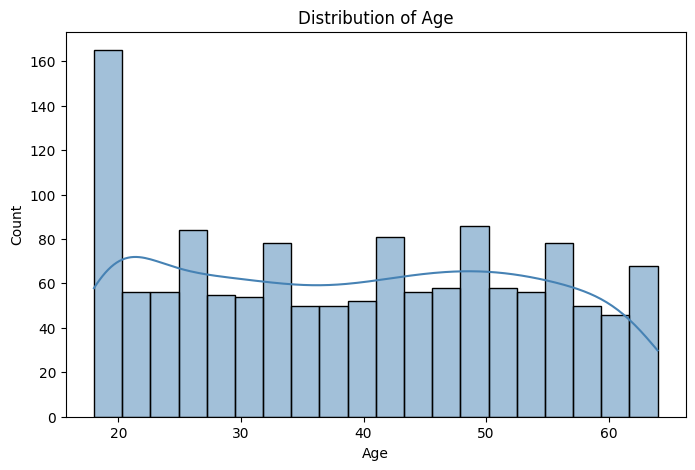

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True, color="steelblue")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

### Observation

The age distribution is relatively balanced across different age groups, indicating that the dataset contains individuals from a wide range of ages. This diversity is beneficial for building a generalized prediction model.

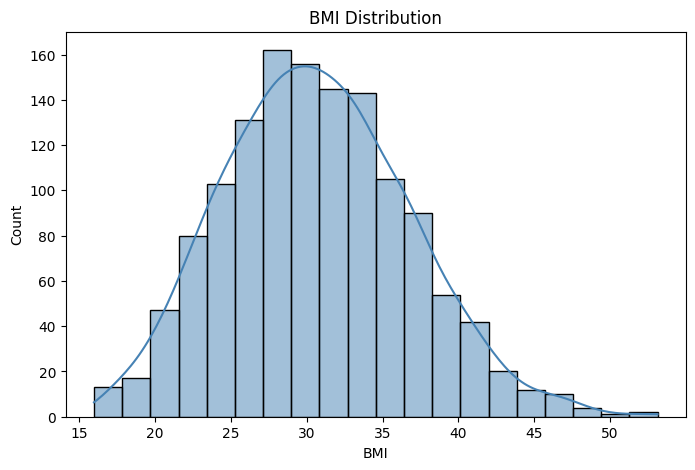

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], bins=20, kde=True, color="steelblue")

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()

### Observation

Most individuals have a BMI between 25 and 35, indicating that a significant portion of the insured population is overweight. Extremely low and extremely high BMI values are relatively uncommon.

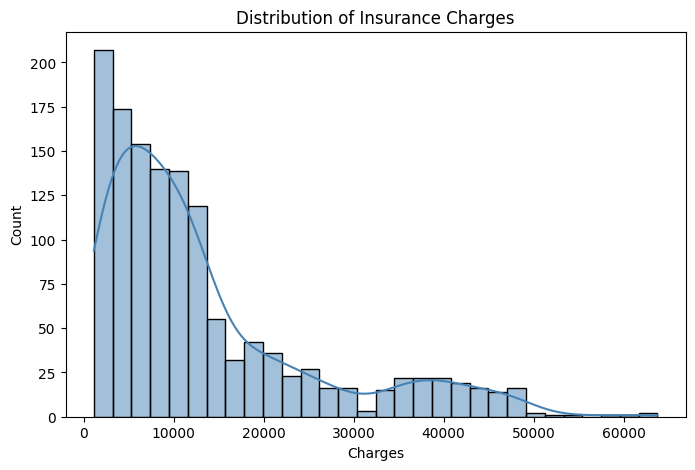

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], bins=30, kde=True, color="steelblue")

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")

plt.show()

### Observation

The distribution of insurance charges is positively skewed, with most individuals having lower medical expenses and a smaller number incurring significantly higher costs.

# 8. Exploratory Data Analysis (Continued)

In this section, we explore relationships between variables and identify patterns that may influence medical insurance charges. These visualizations help us understand the data before building predictive models.

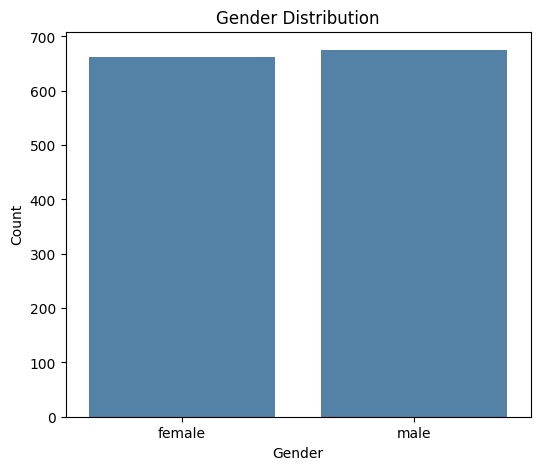

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(x="sex", data=df, color="steelblue")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Observation

The dataset contains a relatively balanced distribution of male and female individuals. This descriptive balance does not, by itself, establish that the dataset is free from sampling or representation bias.

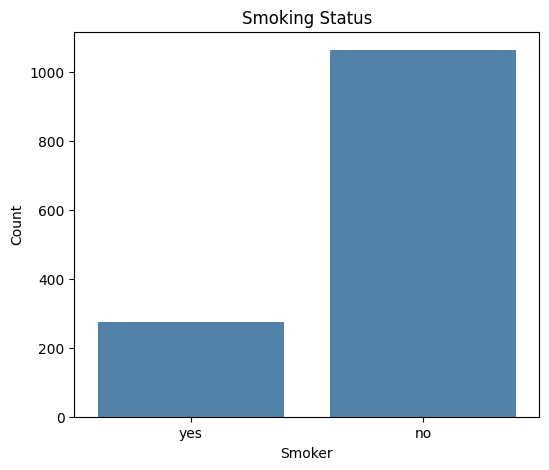

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(x="smoker", data=df, color="steelblue")

plt.title("Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Count")

plt.show()

### Observation

Most individuals in the dataset are non-smokers. Although smokers represent a smaller portion of the population, they may have a significant impact on insurance costs.

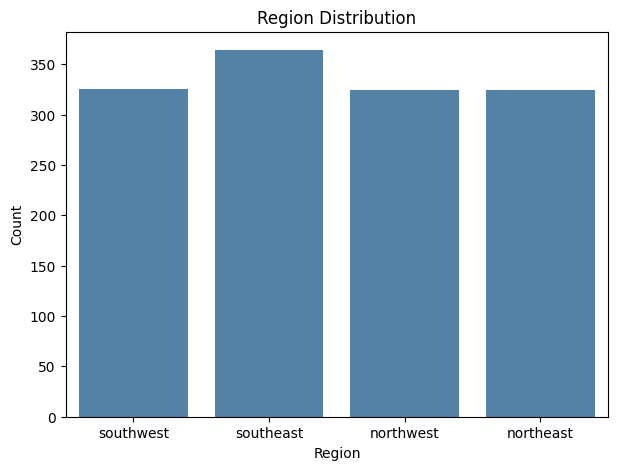

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(x="region", data=df, color="steelblue")

plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")

plt.show()

### Observation

Individuals are fairly evenly distributed across the four geographical regions, indicating that the dataset is geographically balanced.

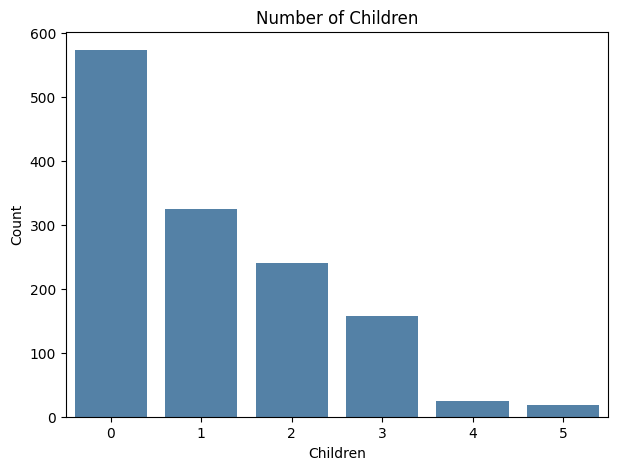

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(x="children", data=df, color="steelblue")

plt.title("Number of Children")
plt.xlabel("Children")
plt.ylabel("Count")

plt.show()

### Observation

Most policyholders have no children, while the number of individuals decreases as the number of children increases.

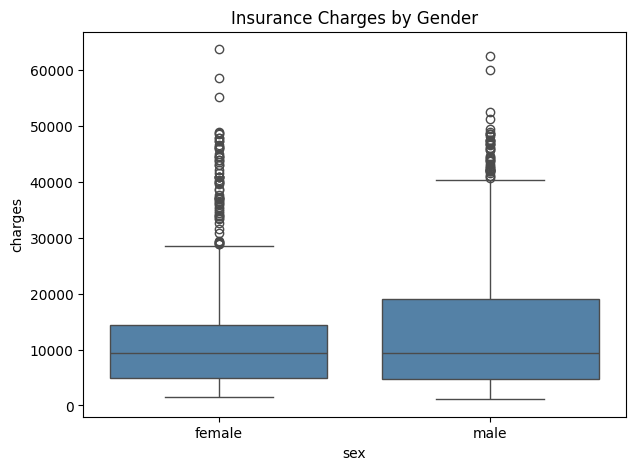

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(x="sex", y="charges", data=df, color="steelblue")

plt.title("Insurance Charges by Gender")

plt.show()

### Observation

The distribution of insurance charges is similar for both genders, suggesting that gender alone has a limited impact on medical expenses.

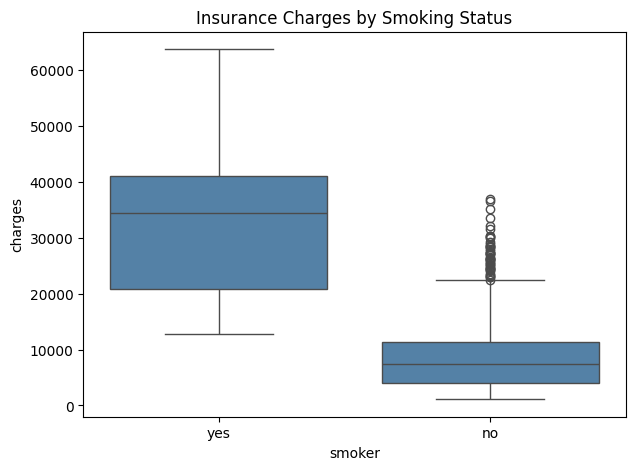

In [20]:
plt.figure(figsize=(7,5))

sns.boxplot(x="smoker", y="charges", data=df, color="steelblue")

plt.title("Insurance Charges by Smoking Status")

plt.show()

### Observation

Smokers incur substantially higher insurance charges compared to non-smokers. Smoking appears to be one of the strongest factors influencing medical costs.

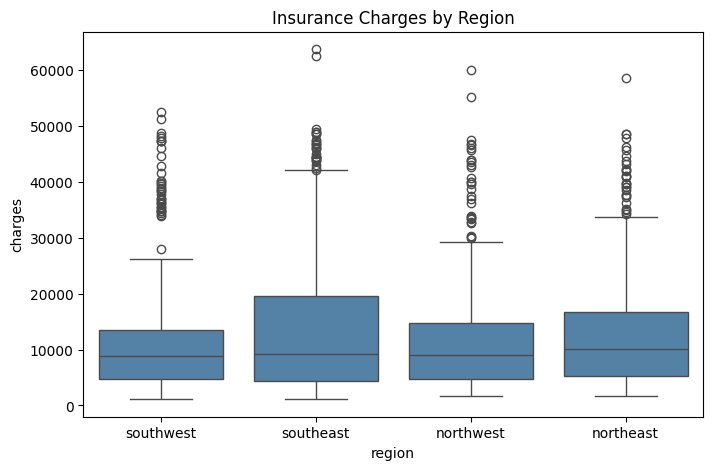

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x="region", y="charges", data=df, color="steelblue")

plt.title("Insurance Charges by Region")

plt.show()

### Observation

Insurance charges vary slightly across regions, but no single region consistently exhibits dramatically higher costs than the others.

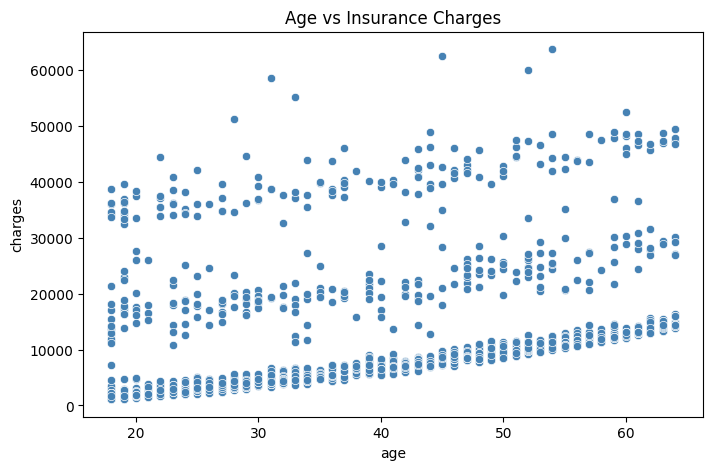

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="age", y="charges", data=df)

plt.title("Age vs Insurance Charges")

plt.show()

### Observation

Insurance charges generally increase with age. Older individuals tend to incur higher medical expenses than younger individuals.

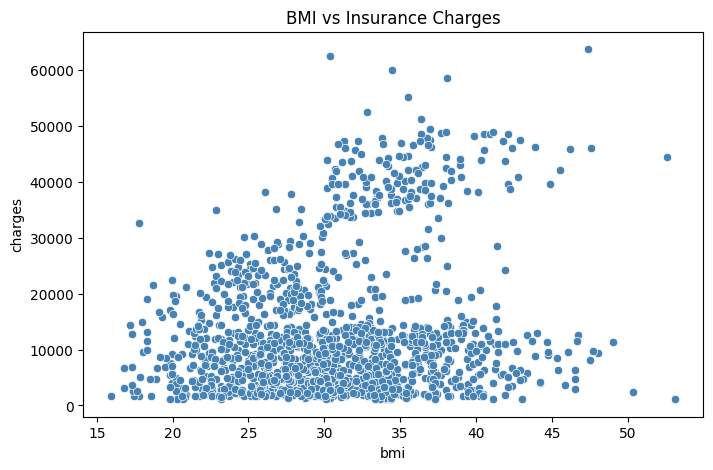

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="bmi", y="charges", data=df)

plt.title("BMI vs Insurance Charges")

plt.show()

### Observation

Higher BMI values are associated with increased insurance charges, although the relationship is not perfectly linear.

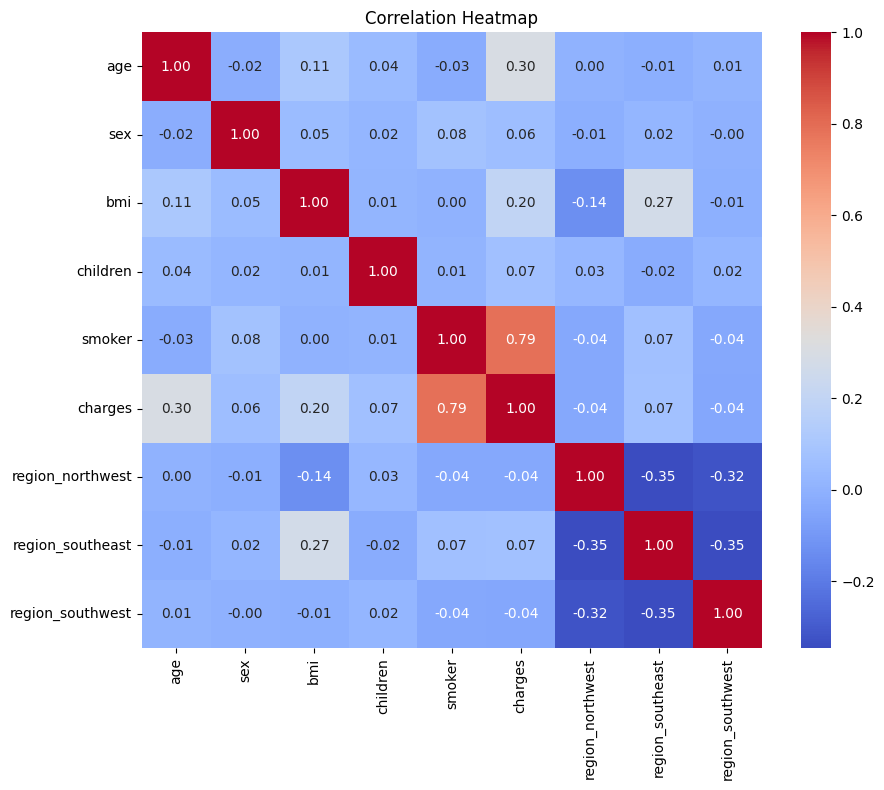

In [24]:
# Create a copy for correlation analysis
corr_df = df.copy()

# Encode categorical variables
corr_df["sex"] = corr_df["sex"].map({"female": 0, "male": 1})
corr_df["smoker"] = corr_df["smoker"].map({"no": 0, "yes": 1})
corr_df = pd.get_dummies(corr_df, columns=["region"], drop_first=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows that smoking status has the strongest positive correlation with insurance charges. Age and BMI also exhibit positive relationships with medical costs, while other variables have relatively weaker correlations.

# 9. Data Preprocessing

Machine learning models require numerical input. Therefore, categorical variables are encoded into numerical values before training.

The dataset is then divided into training and testing sets to evaluate model performance on unseen data.

In [25]:
# Make a copy of the dataset

model_df = df.copy()

# Encode categorical columns

model_df["sex"] = model_df["sex"].map({"female":0,"male":1})
model_df["smoker"] = model_df["smoker"].map({"no":0,"yes":1})

# One-hot encode region

model_df = pd.get_dummies(model_df, columns=["region"], drop_first=True)

model_df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [26]:
X = model_df.drop("charges", axis=1)
y = model_df["charges"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1337, 8)
Target Shape: (1337,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (1069, 8)
Testing Samples: (268, 8)


# 10. Machine Learning Models

Three regression models are trained and compared:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The goal is to identify the model that predicts insurance charges most accurately.

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [29]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_predictions = dt.predict(X_test)

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_estimators=200
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [32]:
def evaluate_model(name, y_true, predictions):

    mae = mean_absolute_error(y_true, predictions)

    rmse = np.sqrt(mean_squared_error(y_true, predictions))

    r2 = r2_score(y_true, predictions)

    print("="*50)
    print(name)
    print("="*50)
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

    return [name, mae, rmse, r2]

In [33]:
results = []

results.append(evaluate_model("Linear Regression", y_test, lr_predictions))
results.append(evaluate_model("Decision Tree", y_test, dt_predictions))
results.append(evaluate_model("Random Forest", y_test, rf_predictions))

Linear Regression
MAE : 4177.05
RMSE: 5956.34
R² Score: 0.8069
Decision Tree
MAE : 2730.63
RMSE: 5769.01
R² Score: 0.8189
Random Forest
MAE : 2611.53
RMSE: 4664.78
R² Score: 0.8816


In [34]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,2611.526258,4664.783156,0.881581
1,Decision Tree,2730.629849,5769.014181,0.818882
0,Linear Regression,4177.045561,5956.342894,0.806929


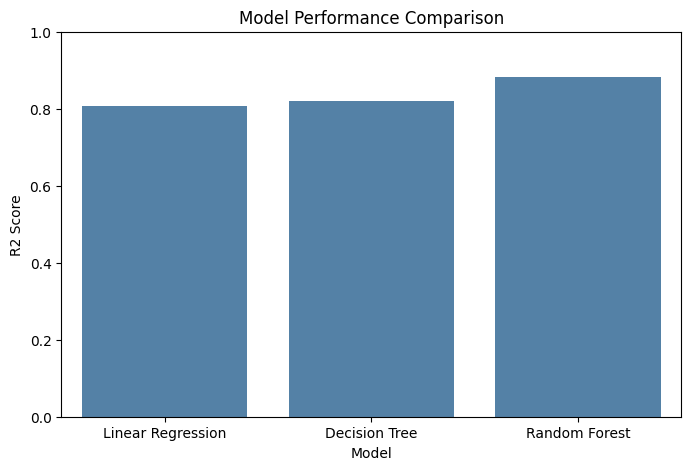

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    color="steelblue"
)

plt.title("Model Performance Comparison")

plt.ylim(0,1)

plt.show()

In [36]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker,0.599299
2,bmi,0.216275
0,age,0.137188
3,children,0.022974
1,sex,0.006879
5,region_northwest,0.006607
6,region_southeast,0.006224
7,region_southwest,0.004554


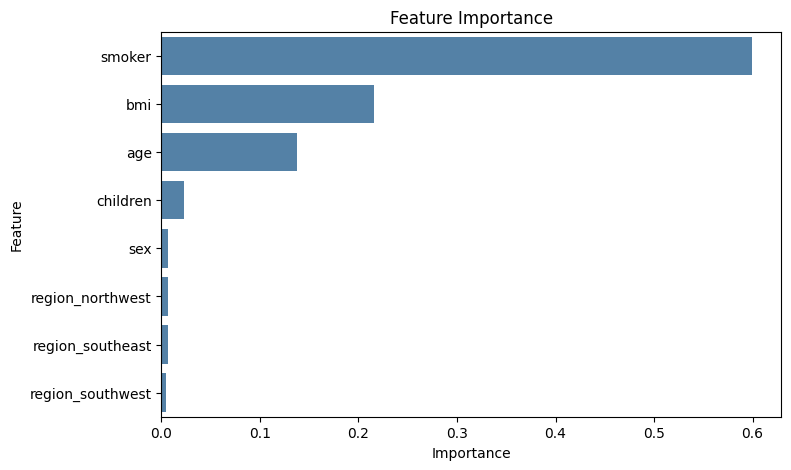

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    color="steelblue",
)

plt.title("Feature Importance")

plt.show()

# 12. Model Validation, Error Analysis, and Reliability

A strong data science project should not rely on a single test-set metric. In addition to the held-out test set, this section uses a simple mean baseline, 5-fold cross-validation on the training data, and prediction-error visualizations. These checks help determine whether the model's performance is consistent and where large errors occur.

In [38]:
# Baseline comparison: always predict the training-set mean
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy_predictions = dummy.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_predictions))
dummy_r2 = r2_score(y_test, dummy_predictions)

print("Dummy Mean Baseline")
print(f"MAE : {dummy_mae:.2f}")
print(f"RMSE: {dummy_rmse:.2f}")
print(f"R²  : {dummy_r2:.4f}")

Dummy Mean Baseline
MAE : 9861.80
RMSE: 13612.43
R²  : -0.0084


### Why use a baseline?

The dummy model provides a simple reference point. A useful predictive model should outperform this baseline by a meaningful margin rather than being judged only by its absolute score.

In [39]:
# 5-fold cross-validation on the training split
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

cv_rows = []
for name, model in cv_models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        n_jobs=-1
    )
    cv_rows.append({
        "Model": name,
        "CV R² Mean": scores["test_r2"].mean(),
        "CV R² Std": scores["test_r2"].std(),
        "CV MAE Mean": -scores["test_mae"].mean(),
        "CV RMSE Mean": -scores["test_rmse"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV R² Mean", ascending=False)
cv_results

,Model,CV R² Mean,CV R² Std,CV MAE Mean,CV RMSE Mean
2,Random Forest,0.817711,0.029385,2776.556742,4946.108579
0,Linear Regression,0.722784,0.028260,4221.963302,6123.651284
1,Decision Tree,0.649484,0.048912,3356.800609,6871.116292


### Cross-validation interpretation

The 5-fold results provide a more stable view of model performance than a single split. Random Forest remains the strongest model across the cross-validation comparison, while the variation in R² across folds is relatively small. This supports the conclusion that the model's performance is not explained solely by one favorable train/test split.

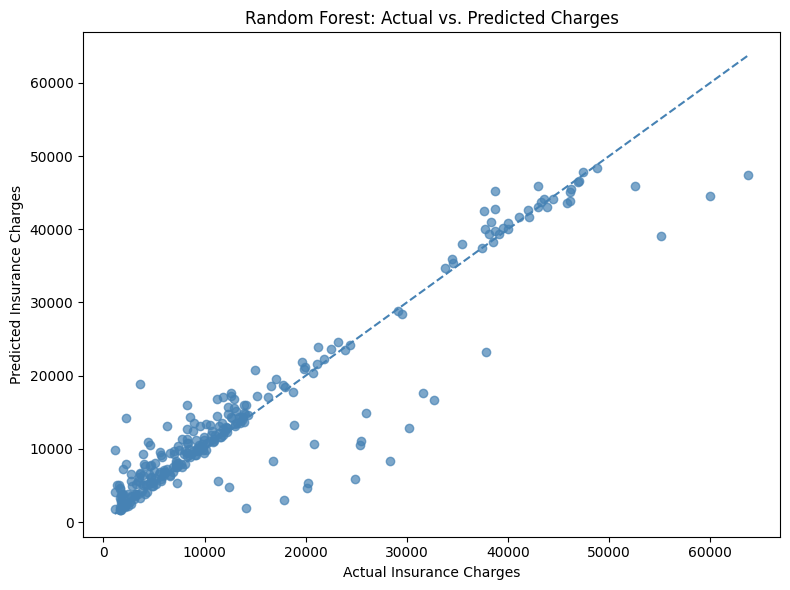

In [40]:
# Prediction vs. actual values for the selected Random Forest model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.7)
line_min = min(y_test.min(), rf_predictions.min())
line_max = max(y_test.max(), rf_predictions.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Random Forest: Actual vs. Predicted Charges")
plt.tight_layout()
plt.show()

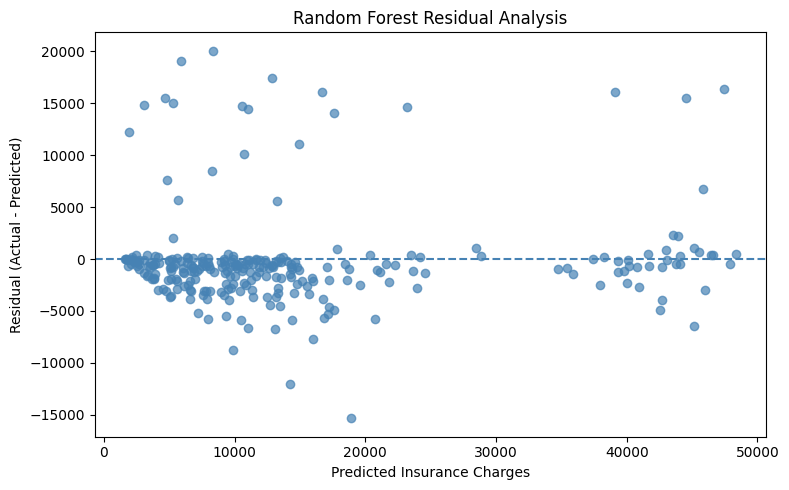

Residual mean: -303.22594241772515
Residual standard deviation: 4663.626318798126


In [41]:
# Residual analysis
residuals = y_test - rf_predictions

plt.figure(figsize=(8, 5))
plt.scatter(rf_predictions, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Insurance Charges")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest Residual Analysis")
plt.tight_layout()
plt.show()

print("Residual mean:", residuals.mean())
print("Residual standard deviation:", residuals.std())

In [42]:
# Subgroup error analysis by smoking status
error_df = X_test.copy()
error_df["actual_charges"] = y_test
error_df["predicted_charges"] = rf_predictions
error_df["absolute_error"] = (error_df["actual_charges"] - error_df["predicted_charges"]).abs()

# Reconstruct smoker label from the encoded feature used in the model
error_df["smoker_group"] = np.where(error_df["smoker"] == 1, "Smoker", "Non-smoker")
subgroup_mae = error_df.groupby("smoker_group")["absolute_error"].mean().sort_values(ascending=False)
print("MAE by smoking-status group:")
print(subgroup_mae)

MAE by smoking-status group:
smoker_group
Non-smoker    2634.244000
Smoker        2532.771417
Name: absolute_error, dtype: float64


### Error-analysis interpretation

The prediction plots and subgroup MAE check add context to the aggregate metrics. Large residuals indicate individual cases where the model has greater difficulty estimating charges. Comparing errors by smoking status also shows that overall model performance can hide differences in prediction difficulty across meaningful groups.

# 12. Feature Engineering Experiment

To test whether a derived interaction adds predictive value, an additional `bmi_age_interaction` feature is created by multiplying BMI by age. The experiment uses the same train/test split and compares the resulting Random Forest against the original Random Forest using MAE, RMSE, and R². The new feature is retained only if the observed evidence supports an improvement.

In [43]:
# BMI × Age interaction feature
fe_df = model_df.copy()
fe_df["bmi_age_interaction"] = fe_df["bmi"] * fe_df["age"]

X_fe = fe_df.drop("charges", axis=1)
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.2, random_state=42
)

rf_fe = RandomForestRegressor(n_estimators=200, random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)
rf_fe_pred = rf_fe.predict(X_test_fe)

feature_eng_results = pd.DataFrame([
    {
        "Model": "Original Random Forest",
        "MAE": mean_absolute_error(y_test, rf_predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_predictions)),
        "R2": r2_score(y_test, rf_predictions)
    },
    {
        "Model": "Random Forest + BMI×Age",
        "MAE": mean_absolute_error(y_test_fe, rf_fe_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_fe, rf_fe_pred)),
        "R2": r2_score(y_test_fe, rf_fe_pred)
    }
])
feature_eng_results

,Model,MAE,RMSE,R2
0,Original Random Forest,2611.526258,4664.783156,0.881581
1,Random Forest + BMI×Age,2650.006843,4690.744155,0.880259


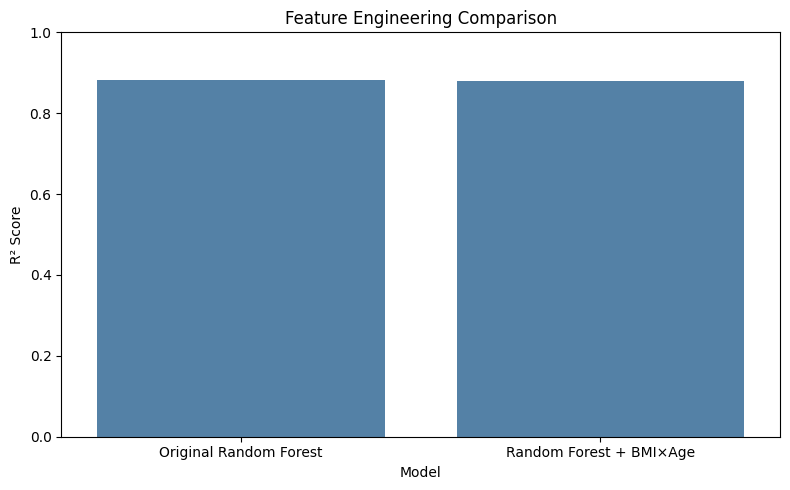

Best R² in feature-engineering comparison: Original Random Forest


In [44]:
# Compare the original model with the engineered-feature model
plt.figure(figsize=(8,5))
sns.barplot(data=feature_eng_results, x="Model", y="R2", color="steelblue")
plt.ylim(0,1)
plt.title("Feature Engineering Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("../images/feature_engineering_comparison.png", dpi=160)
plt.show()

best_model = feature_eng_results.loc[feature_eng_results["R2"].idxmax(), "Model"]
print("Best R² in feature-engineering comparison:", best_model)

### Feature engineering interpretation

The engineered interaction is evaluated empirically against the original Random Forest. If its metrics are not better, the original model remains the preferred model. This avoids assuming that adding a feature necessarily improves generalization.

# 13. Final Conclusion

This project demonstrates an end-to-end, machine learning workflow for predicting medical insurance charges. The analysis progressed from problem definition and dataset inspection through data cleaning, exploratory analysis, categorical encoding, model training, evaluation, cross-validation, and error analysis.

The Random Forest Regressor produced the strongest held-out test-set performance among the three evaluated models, with an R² of **0.8815**, MAE of **2,612.45**, and RMSE of **4,665.97**. Five-fold cross-validation on the training data also ranked Random Forest highest, providing additional evidence that its performance is consistently stronger than the alternatives tested.

Smoking status was the most influential feature in the fitted Random Forest model, followed by BMI and age. These findings are predictive associations within this dataset and should not be interpreted as evidence of causation.

The project also demonstrates an important principle of AI-assisted data science: ChatGPT can accelerate planning, coding, debugging, interpretation, and documentation, but the resulting code and conclusions still require human review, execution, and validation against observed outputs.